# RQ3: Exploratory Correlation Analysis of Demographic and Dispositional Variables

This notebook investigates bivariate relationships between demographic characteristics, dispositional traits, and measures of trust, system understanding, and mental workload.

The analysis consists of:

1. Computation of Spearman rank correlations.
2. Multiple comparison correction using the Benjamini–Hochberg false discovery rate procedure.
3. Visualization of significant and non-significant associations in a correlation matrix.
4. Export of correlation statistics for further reporting.

The following variables were included:

- **Outcome variables**
  - Trust
  - System Understanding
  - Mental Workload

- **Dispositional variables**
  - Technology Readiness
  - Need for Cognition
  - Big Five personality traits:
    - Extraversion
    - Agreeableness
    - Conscientiousness
    - Negative Emotionality
    - Openness

- **Demographic and experience variables**
  - Age
  - Driving Frequency
  - Driver's License
  - Automation Experience
  - VR Experience


In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# for spearman matrix heatmap
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.stats.multitest import multipletests

# for excel table
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from openpyxl.utils import get_column_letter


## Load data

In [ ]:
df = pd.read_pickle("../DATA/demographics.pkl")
blocks = pd.read_pickle("../DATA/blocks.pkl")

df = (
    blocks
    .merge(df, on="participant_id", how="left")
    .replace({
        "condition": {
            "Nelo": "Baseline",
            "Coda": "Proactive",
            "Lumo": "Optional",
        }
    })
)

df["block"] = df["block"].astype("category")

LABELS = {
    "trust": "Trust Score",
    "understanding": "System Understanding Score",
    "nasa": "Workload",
    "tri_score": "Technology Readiness Index",
    "nfc_score": "Need for Cognition",
    "bfi_extraversion": "Extraversion",
    "bfi_agreeableness": "Agreeableness",
    "bfi_conscientiousness": "Conscientiousness",
    "bfi_neuroticism": "Neuroticism",
    "bfi_openness": "Openness",
}

BFI_COLS = [
    "bfi_extraversion",
    "bfi_agreeableness",
    "bfi_conscientiousness",
    "bfi_neuroticism",
    "bfi_openness",
]

PREDICTORS = [
    "tri_score",
    "nfc_score",
    *BFI_COLS,
    "driving_frequency_num",
    "drivers_license_num",
    "automation_experience_num",
    "age",
]

OUTCOMES = ["trust", "understanding", "nasa"]

sns.set_theme(style="whitegrid", font_scale=1.4)


MAPS = {
    "driving_frequency": {
        "never": 0,
        "rarely": 1,
        "several times a week": 2,
        "daily": 3,
    },
    "automation_experience": {
        "no": 0,
        "yes": 1,
        "not sure": 0,
    },
    "drivers_license": {
        "no": 0,
        "yes": 1,
    },
    "vr_experience": {
        "no": 0,
        "yes": 1,
    },
}

for column, mapping in MAPS.items():
    df[f"{column}_num"] = df[column].str.lower().map(mapping)

df["age"] = 2026 - df["birth_year"]

df_corr = pd.DataFrame(
    [
        {
            "predictor": predictor,
            "outcome": outcome,
            "correlation": spearmanr(df[predictor], df[outcome]).statistic,
            "p_value": spearmanr(df[predictor], df[outcome]).pvalue,
        }
        for predictor in PREDICTORS
        for outcome in OUTCOMES
    ]
)

df_corr

In [9]:
VAR_LABELS = {
    "trust": "Trust",
    "understanding": "System Understanding",
    "nasa": "Mental Workload",
    "technology_readiness": "Technology Readiness",
    "tri": "Technology Readiness",
    "tri_score": "Technology Readiness",
    "nfc": "Need for Cognition",
    "nfc_score": "Need for Cognition",
    "need_for_cognition": "Need for Cognition",
    "bfi_extraversion": "Extraversion",
    "bfi_agreeableness": "Agreeableness",
    "bfi_conscientiousness": "Conscientiousness",
    "bfi_neuroticism": "Negative Emotionality",
    "bfi_openness": "Openness",
    "age": "Age",
    "automation_experience": "Automation Experience",
    "automation_familiarity": "Automation Familiarity",
    "driving_frequency_num": "Driving Frequency",
    "automation_experience_num": "Automation Experience",
    "drivers_license_num": "Driver's License",
    "vr_experience_num": "VR Experience",
}

cols = PREDICTORS + OUTCOMES
data = df[cols]

n = len(cols)
rho = np.eye(n)
pvals = np.zeros((n, n))
lower = np.tril_indices(n, k=-1)

for i, j in zip(*lower):
    r, p = stats.spearmanr(data.iloc[:, i], data.iloc[:, j], nan_policy="omit")

    rho[i, j] = rho[j, i] = r
    pvals[i, j] = pvals[j, i] = p

labels = [VAR_LABELS.get(c, c) for c in cols]

## Full Spearman Matrix

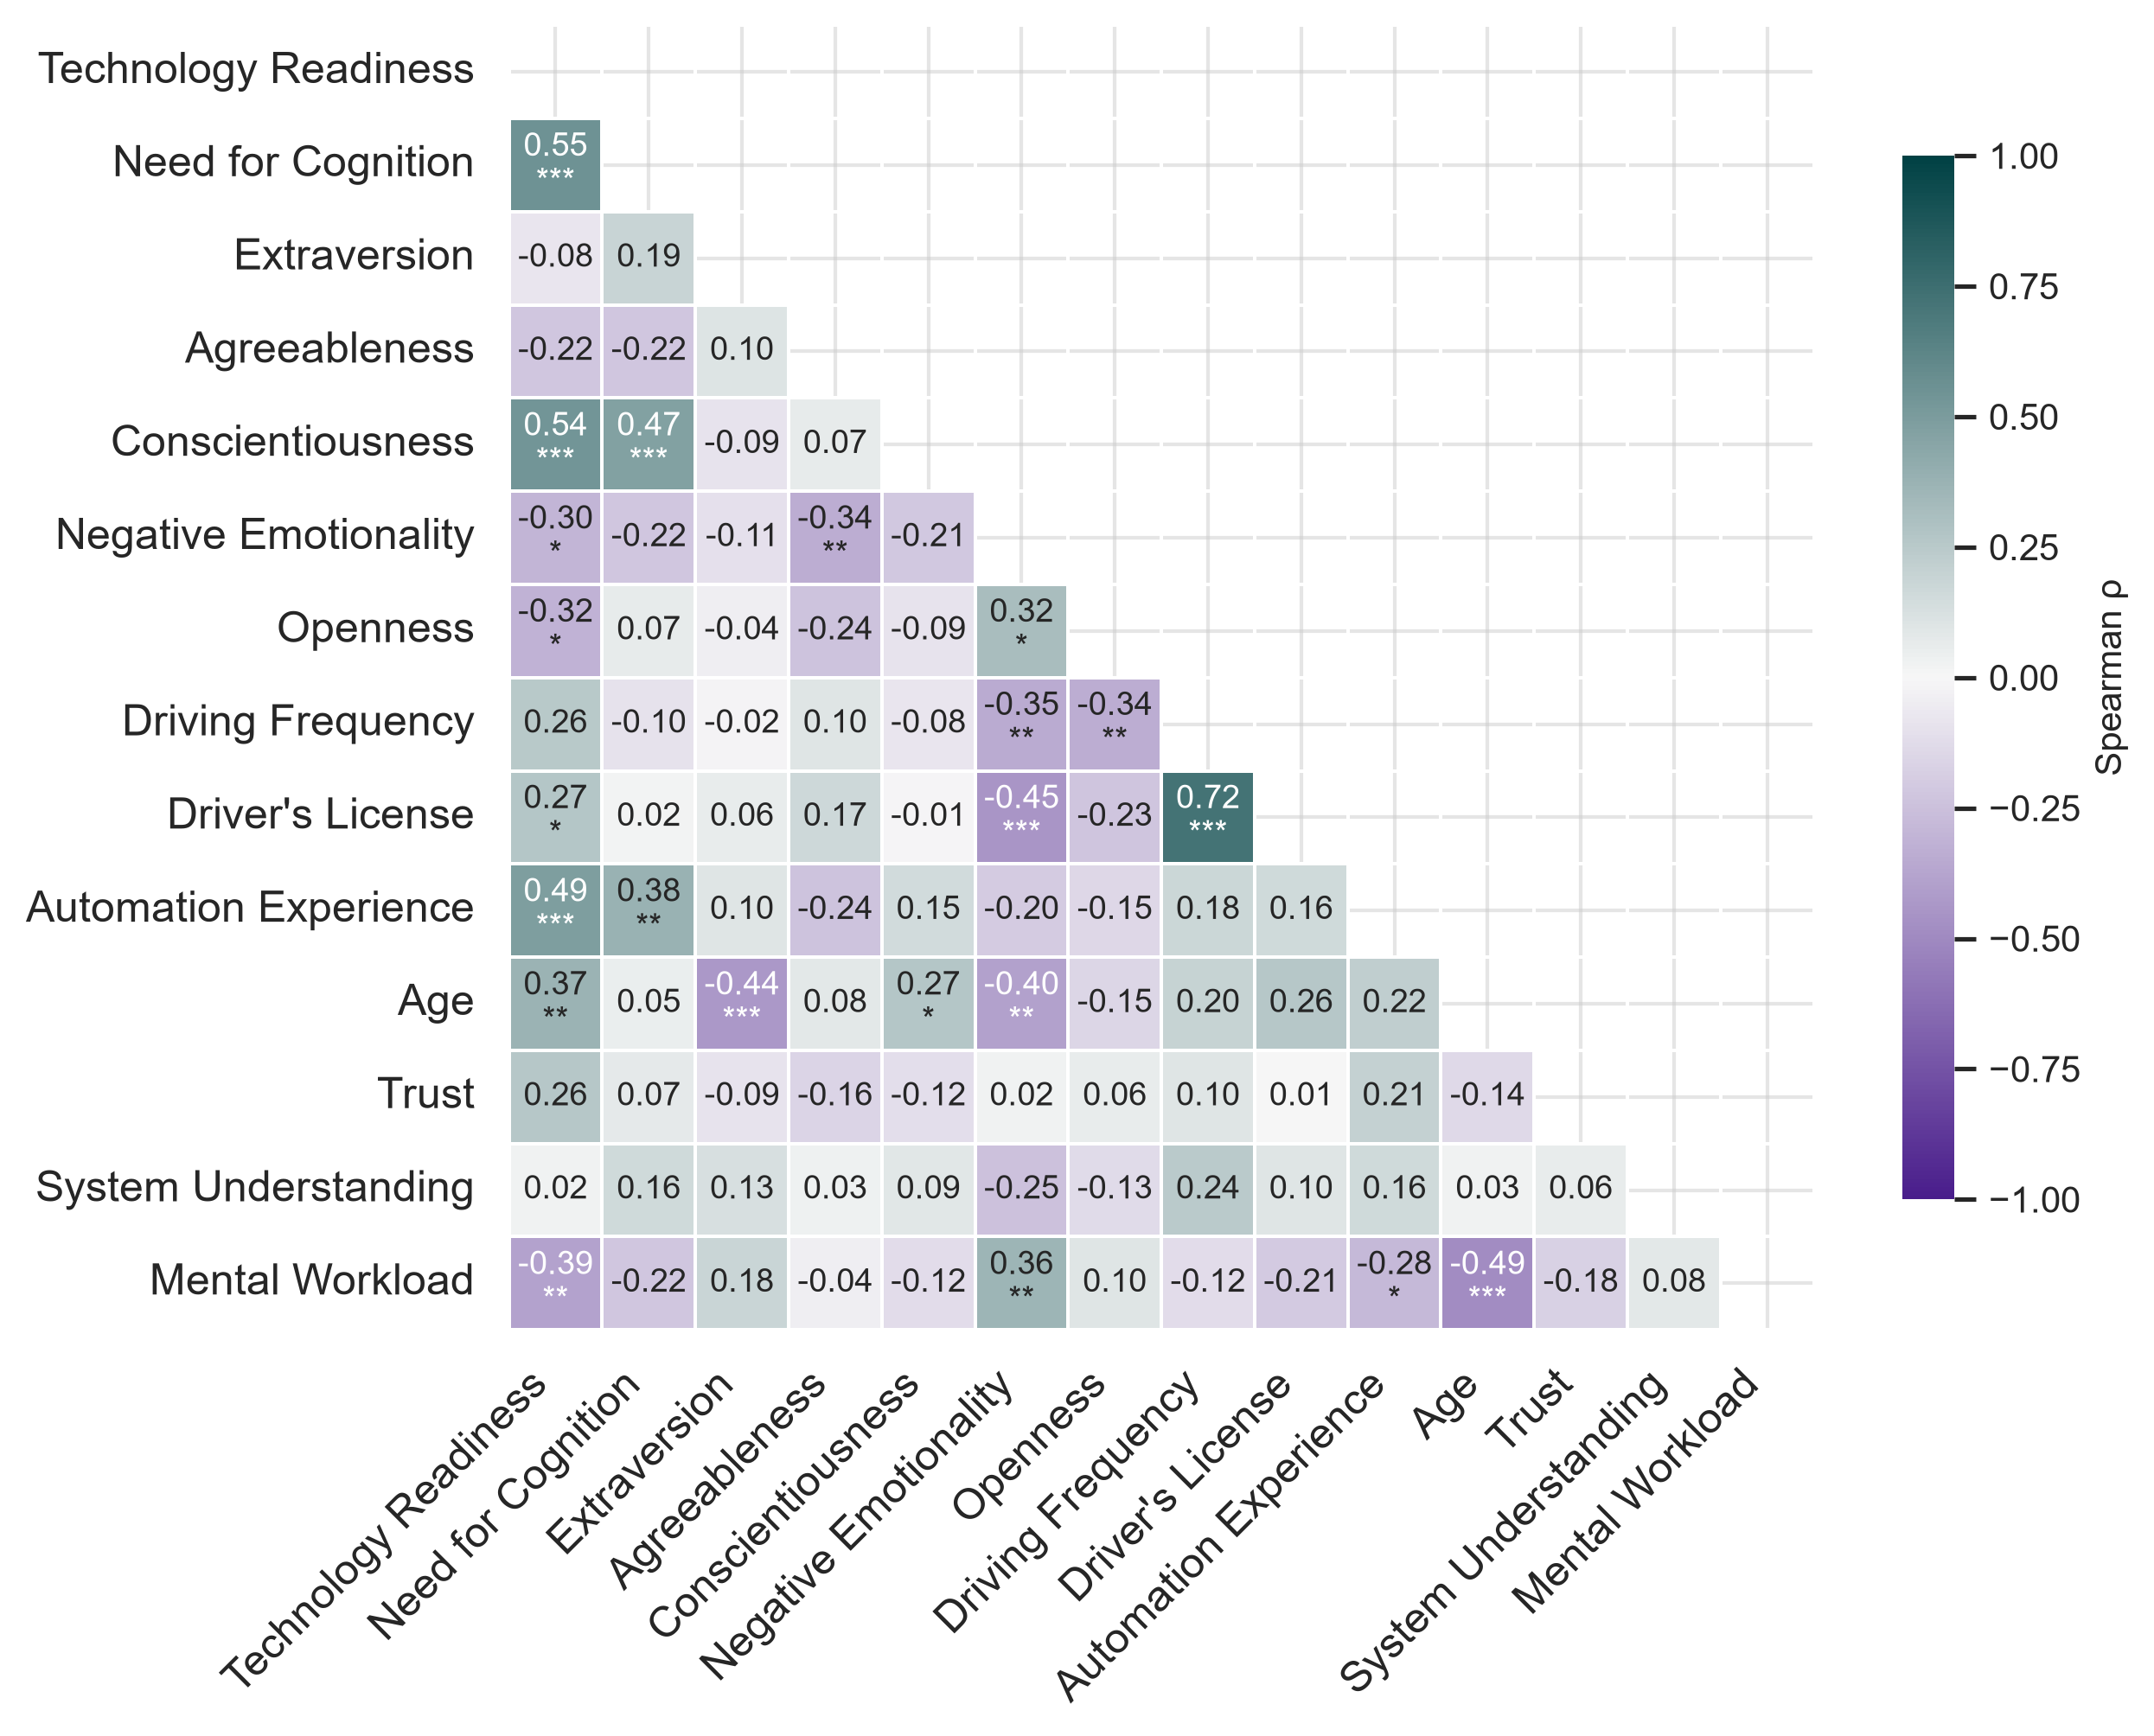

In [10]:
lower_idx = np.tril_indices(n, k=-1)
p_vals_flat = pvals[lower_idx]

reject, p_corrected_flat, _, _ = multipletests(
    p_vals_flat,
    method="fdr_bh"
)

sig_mat = np.zeros((n, n), dtype=bool)
sig_mat[lower_idx] = reject


def stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

annot = np.full((n, n), "", dtype=object)

for (i, j), p_corr in zip(zip(*lower_idx), p_corrected_flat):
    value = f"{rho[i, j]:.2f}"

    if sig_mat[i, j]:
        annot[i, j] = f"{value}\n{stars(p_corr)}"
    else:
        annot[i, j] = value

annot_df = pd.DataFrame(
    annot,
    index=labels,
    columns=labels,
)


corr_df = pd.DataFrame(rho, index=labels, columns=labels)

upper = np.triu(np.ones((n, n), dtype=bool))

sig_lower = np.zeros((n, n), dtype=bool)
sig_lower[lower_idx] = sig_mat[lower_idx]

fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

cmap = LinearSegmentedColormap.from_list(
    "custom_diverging",
    ["#491d8b", "#f7f7f7", "#004144"],
)

mask = np.triu(np.ones((n, n), dtype=bool))

sns.heatmap(
    corr_df,
    mask=mask,
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    annot=annot_df,
    fmt="",
    annot_kws={"size": 9},
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Spearman ρ",
        "shrink": 0.8,
    },
    ax=ax,
)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Spearman ρ", size=10)

ax.tick_params(axis="x", rotation=45, labelsize=12)
ax.tick_params(axis="y", rotation=0, labelsize=12)

plt.setp(ax.get_xticklabels(), ha="right")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Spearman Matrix Masked Version

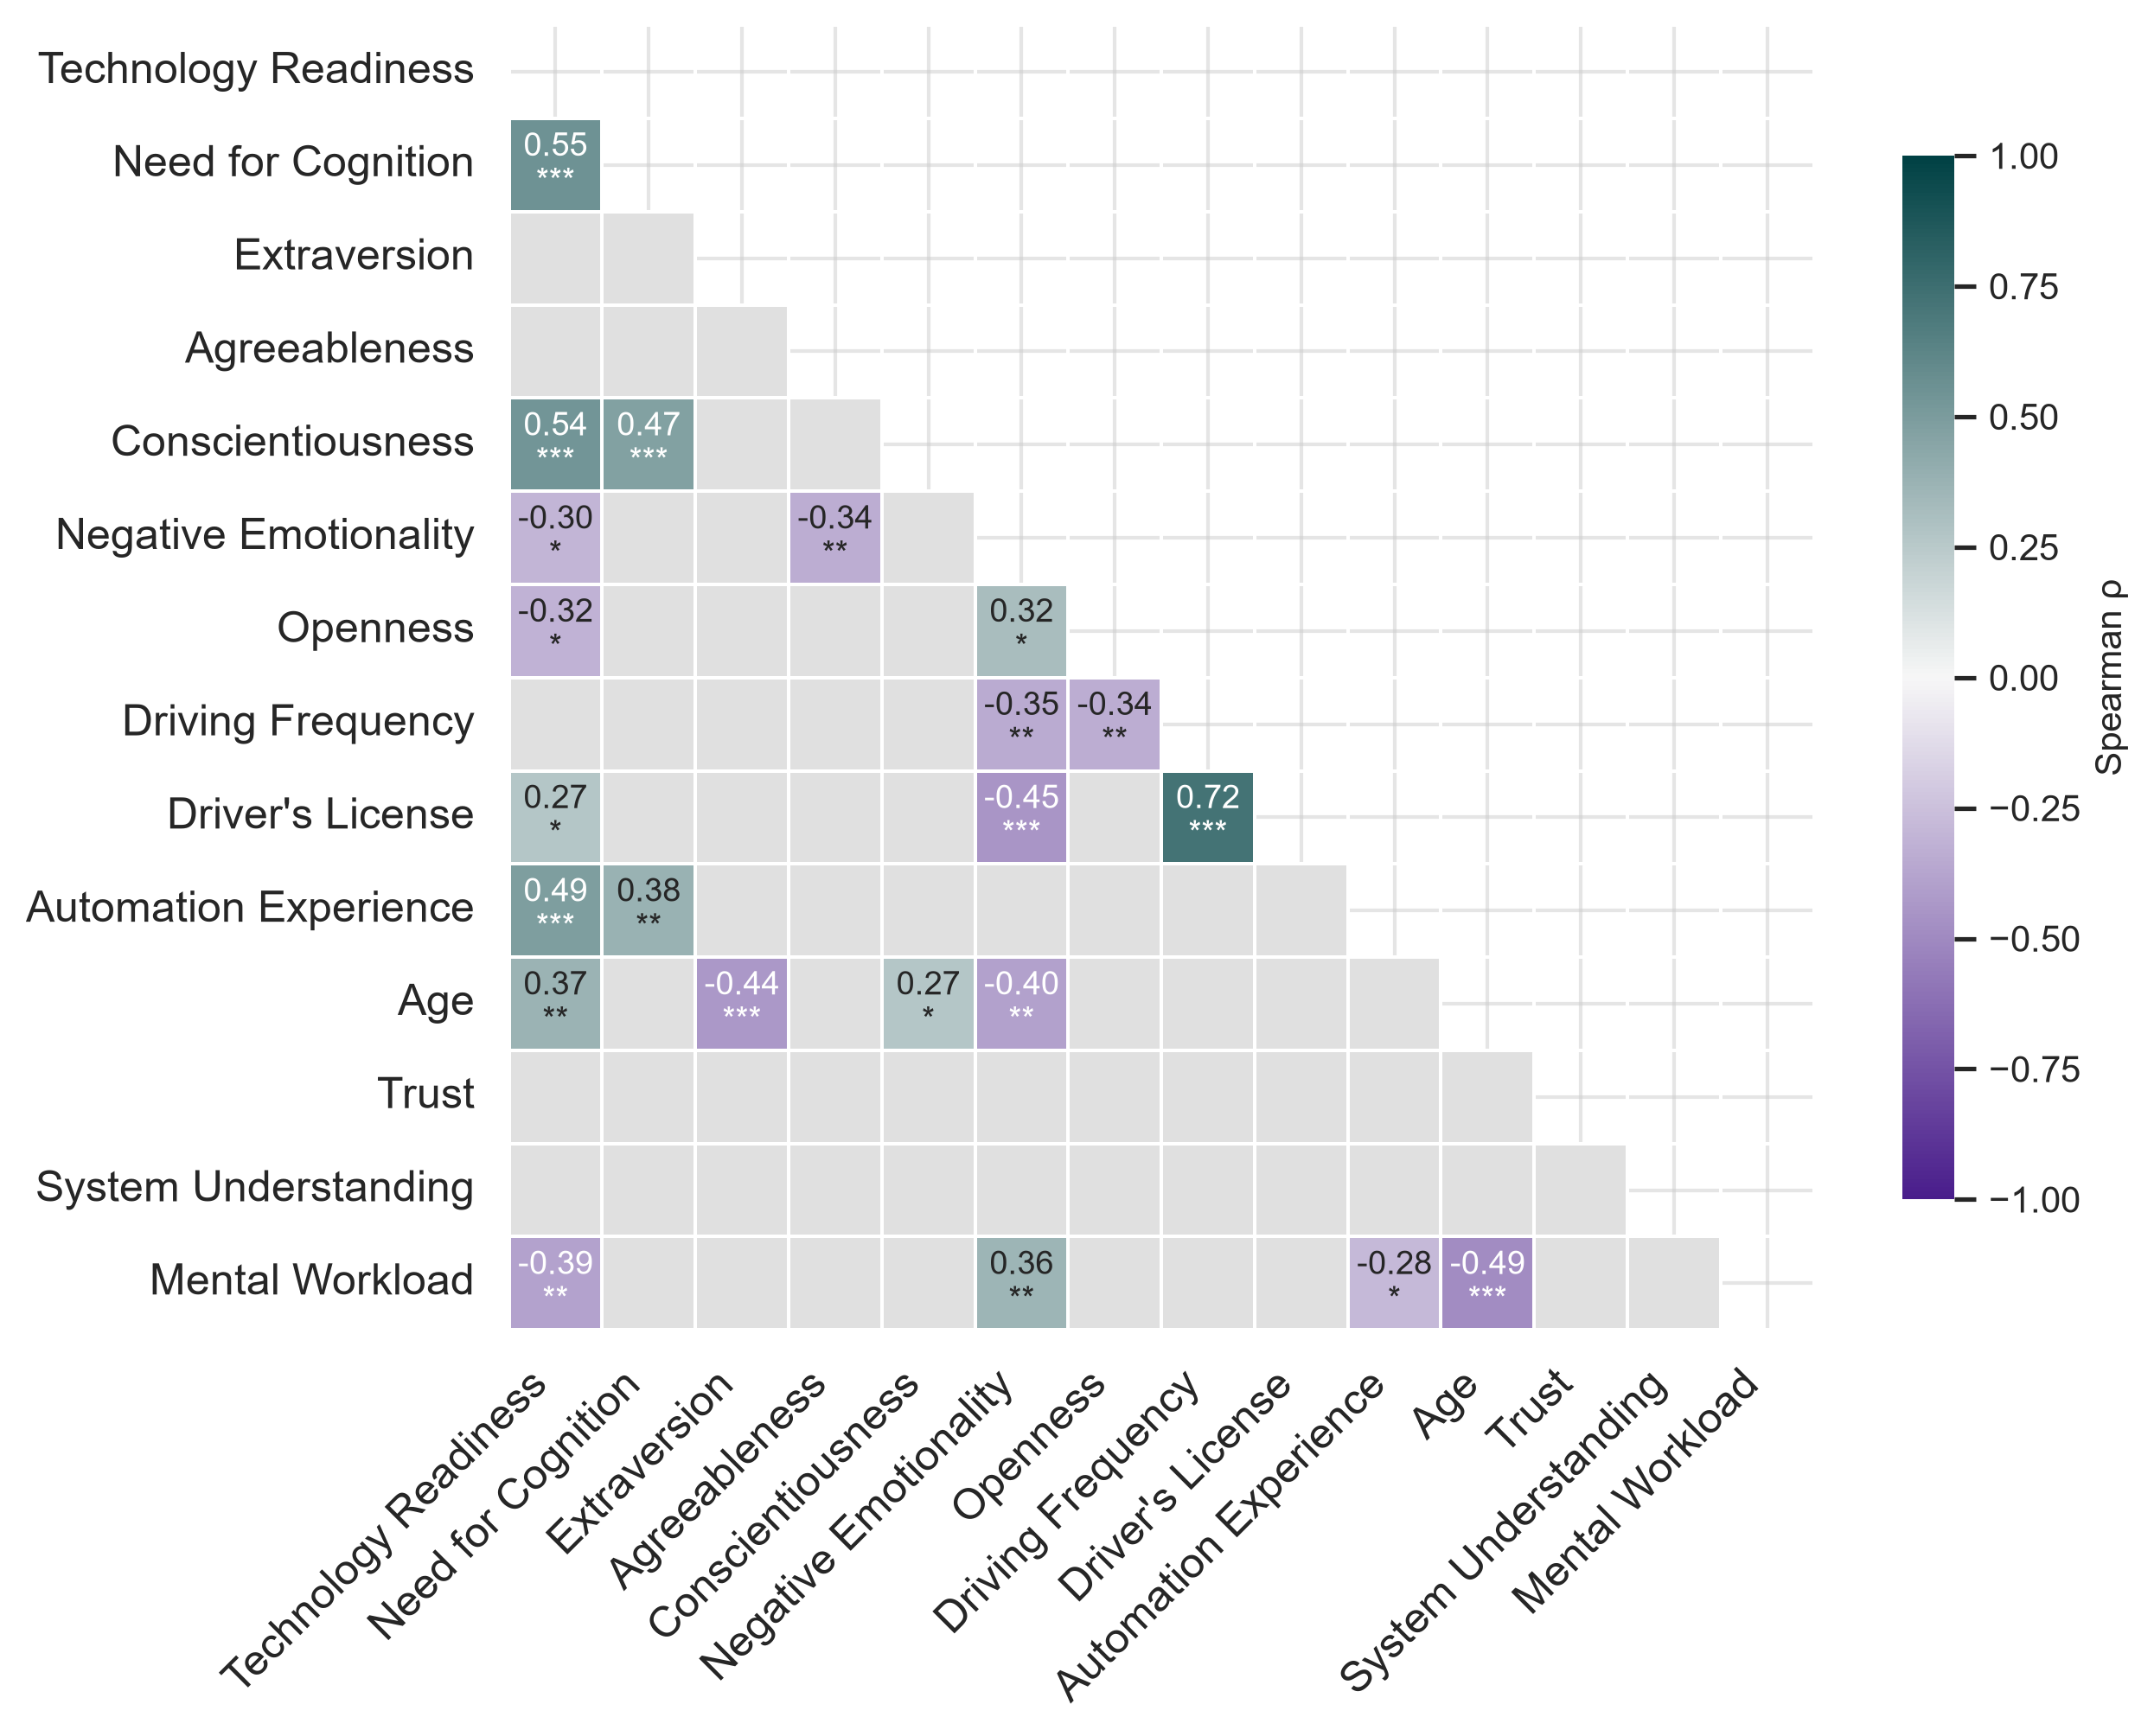

In [12]:
annot = np.full((n, n), "", dtype=object)

for (i, j), p_corr in zip(zip(*lower_idx), p_corrected_flat):
    if sig_mat[i, j]:
        annot[i, j] = f"{rho[i, j]:.2f}\n{stars(p_corr)}"

corr_df = pd.DataFrame(rho, index=labels, columns=labels)
annot_df = pd.DataFrame(annot, index=labels, columns=labels)


upper = np.triu(np.ones((n, n), dtype=bool))

sig_lower = np.zeros((n, n), dtype=bool)
sig_lower[lower_idx] = sig_mat[lower_idx]

mask_colour = upper | ~sig_lower      # only significant lower triangle
mask_grey   = upper | sig_lower       # only non-significant lower triangle


fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

cmap = LinearSegmentedColormap.from_list(
    "custom_diverging",
    ["#491d8b", "#f7f7f7", "#004144"],
)

grey = LinearSegmentedColormap.from_list(
    "grey",
    ["#e0e0e0", "#e0e0e0"],
)

# Grey layer
sns.heatmap(
    np.zeros((n, n)),
    mask=mask_grey,
    cmap=grey,
    cbar=False,
    square=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Significant correlations
sns.heatmap(
    corr_df,
    mask=mask_colour,
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    annot=annot_df,
    fmt="",
    annot_kws={"size": 9},
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Spearman ρ",
        "shrink": 0.8,
    },
    ax=ax,
)

cbar = ax.collections[1].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Spearman ρ", size=10)

ax.tick_params(axis="x", rotation=45, labelsize=12)
ax.tick_params(axis="y", rotation=0, labelsize=12)

plt.setp(ax.get_xticklabels(), ha="right")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Pairwise Correlation Results
Outputs an excel table.

In [11]:
df_table = pd.DataFrame(
    [
        {
            "Variable 1": labels[i],
            "Variable 2": labels[j],
            "Spearman ρ": round(rho[i, j], 4),
            "p (uncorrected)": round(pvals[i, j], 4),
            "p (FDR-corrected)": round(p_corr, 4),
            "Significant": "Yes" if sig_mat[i, j] else "No",
            "Stars": stars(p_corr) if sig_mat[i, j] else "",
        }
        for (i, j), p_corr in zip(zip(*lower_idx), p_corrected_flat)
    ]
).sort_values("p (FDR-corrected)")


# excel
wb = Workbook()
ws = wb.active
ws.title = "Spearman Correlations"


header_fill   = PatternFill("solid", fgColor="491D8B")
header_font   = Font(bold=True, color="FFFFFF", name="Arial", size=10)
body_font     = Font(name="Arial", size=10)
center_align  = Alignment(horizontal="center", vertical="center")
left_align    = Alignment(horizontal="left",   vertical="center")
thin          = Side(style="thin", color="D0D0D0")
border        = Border(left=thin, right=thin, top=thin, bottom=thin)

headers = list(df_table.columns)
ws.append(headers)

for col, header in enumerate(df_table.columns, start=1):
    cell = ws.cell(1, col, header)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = center_align
    cell.border = border

yes_fill = PatternFill("solid", fgColor="E8F5E9")   # light green for significant
no_fill  = PatternFill("solid", fgColor="F5F5F5")   # light grey for non-significant

for r_idx, row in enumerate(df_table.itertuples(index=False), start=2):
    row_fill = yes_fill if row[5] == "Yes" else no_fill
    for c_idx, value in enumerate(row, start=1):
        cell = ws.cell(row=r_idx, column=c_idx, value=value)
        cell.font      = body_font
        cell.fill      = row_fill
        cell.border    = border
        cell.alignment = center_align if c_idx > 2 else left_align

col_widths = [28, 28, 14, 18, 20, 13, 8]
for i, width in enumerate(col_widths, start=1):
    ws.column_dimensions[get_column_letter(i)].width = width

ws.row_dimensions[1].height = 20
ws.freeze_panes = "A2"   # freeze header row

ws2 = wb.create_sheet("Notes")
ws2["A1"] = "Notes"
ws2["A1"].font = Font(bold=True, name="Arial", size=11)
notes = [
    ("Method",       "Spearman rank correlation"),
    ("Correction",   "Benjamini–Hochberg false discovery rate (FDR)"),
    ("α threshold",  "0.05 (applied to FDR-corrected p-values)"),
    ("Stars",        "* p < .05   ** p < .01   *** p < .001  (corrected)"),
    ("Sorted by",    "FDR-corrected p-value (ascending)"),
]
for r, (key, val) in enumerate(notes, start=2):
    ws2.cell(row=r, column=1, value=key).font  = Font(bold=True, name="Arial", size=10)
    ws2.cell(row=r, column=2, value=val).font  = Font(name="Arial", size=10)
ws2.column_dimensions["A"].width = 20
ws2.column_dimensions["B"].width = 55

wb.save("spearman_correlations.xlsx")
print("Saved: spearman_correlations.xlsx")

Saved: spearman_correlations.xlsx
